# 3.2 - Baseline Models: Linear Regression & Regularization

**Taller de Programación - UBA FCE | Grupo JLP**

---

## Objetivo

Establecer modelos baseline simples para predecir precios de commodities agrícolas:

1. **Linear Regression (OLS):** Modelo más simple, interpretable
2. **Ridge Regression (L2):** Regularización para evitar overfitting
3. **Lasso Regression (L1):** Regularización + selección automática de features
4. **Elastic Net:** Combinación L1 + L2

**Métricas de evaluación:**
- **RMSE** (Root Mean Squared Error): Error en mismas unidades que target
- **MAE** (Mean Absolute Error): Menos sensible a outliers
- **R²**: Porcentaje de varianza explicada
- **Directional Accuracy**: ¿Predecimos correctamente si sube/baja?

## Setup

In [1]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm.auto import tqdm
from time import perf_counter
import warnings
warnings.filterwarnings('ignore')

# Agregar src al path
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR, logger
from utils.cuda_config import get_cuda_config

# Configurar pandas display
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

# Configurar GPU/CUDA
cuda_config = get_cuda_config(verbose=True)

# Configurar CuPy para aceleración GPU en scaling
from utils.cupy_config import get_cupy_config, CUPY_AVAILABLE, get_array_module
cupy_config = get_cupy_config(verbose=True)

# Definir commodities target
TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']

print(f"\n✓ Base directory: {BASE_DIR}")
print(f"✓ Target commodities: {', '.join(TARGET_COMMODITIES)}")


CONFIGURACIÓN DE DISPOSITIVO GPU/CPU
✓ GPU DETECTADA
  - Dispositivo: NVIDIA GeForce RTX 3060
  - Tipo: CUDA
  - Memoria: 12.9 GB

✓ FRAMEWORKS COMPATIBLES:
  - Pytorch: Sí
  - Xgboost: Sí
  - Lightgbm: Sí

CONFIGURACIÓN CuPy - GPU ACCELERATION

1. Sistema operativo: win32
2. Python executable: f:\miniconda\envs\ds\python.exe

3. Configurando CUDA DLL paths (Windows)...
   ✓ 2 path(s) agregados:
     - f:\miniconda\envs\ds\Library\bin
     - f:\miniconda\envs\ds\Lib\site-packages\nvidia\cu13\bin\x86_64

4. Importando CuPy...
   ✓ CuPy importado exitosamente

5. Verificando acceso a GPU...

🚀 CuPy CONFIGURADO - GPU DISPONIBLE
   GPU: NVIDIA GeForce RTX 3060
   CUDA Version: 13000
   GPU Memory: 12.00 GB total
   Free Memory: 10.98 GB
   ✓ Test de operación GPU exitoso


✓ Base directory: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal
✓ Target commodities: Corn, Soybeans, Wheat


## 1. Cargar Features Seleccionadas

In [2]:
# Cargar dataset limpio con features seleccionadas
input_file = PROCESSED_DIR / 'features_selected_modeling.csv'

if not input_file.exists():
    raise FileNotFoundError(
        f"No se encontró {input_file}.\n"
        "Ejecuta notebook 3.1-feature-selection.ipynb primero."
    )

df = pd.read_csv(input_file, parse_dates=['date'])

print(f"✓ Dataset cargado: {input_file.name}")
print(f"  Dimensiones: {df.shape}")
print(f"  Período: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  Missing values: {df.isnull().sum().sum()} (debe ser 0)")

# Verificar que está limpio
assert df.isnull().sum().sum() == 0, "ERROR: Dataset tiene NaNs"

# CRÍTICO: Cargar precios spot para calcular directional accuracy correctamente
# El target es P_{t+7}, pero necesitamos P_t (spot) para medir dirección correctamente
base_file = PROCESSED_DIR / 'commodities_base_consolidated.csv'
if base_file.exists():
    df_base = pd.read_csv(base_file, parse_dates=['date'])
    # Extraer precios spot de los 3 commodities objetivo
    spot_cols = {f'{c}': f'{c}_spot' for c in TARGET_COMMODITIES}
    df_spots = df_base[['date'] + TARGET_COMMODITIES].rename(columns=spot_cols)
    
    # Merge con dataset de modelado
    df = df.merge(df_spots, on='date', how='left')
    print(f"✓ Precios spot agregados para directional accuracy correcta: {list(spot_cols.values())}")
else:
    print(f"⚠️ WARNING: No se encontró {base_file.name} - directional accuracy usará aproximación")

# Separar features y targets
target_cols = [f'{c}_target_t7' for c in TARGET_COMMODITIES]
spot_cols_list = [f'{c}_spot' for c in TARGET_COMMODITIES]
feature_cols = [c for c in df.columns if c not in ['date'] + target_cols + spot_cols_list]

print(f"\nDataset structure:")
print(f"  Features: {len(feature_cols)}")
print(f"  Targets: {len(target_cols)}")
print(f"  Spot prices: {len([c for c in df.columns if '_spot' in c])}")

display(df.head())

✓ Dataset cargado: features_selected_modeling.csv
  Dimensiones: (20166, 38)
  Período: 2000-01-03 → 2025-10-30
  Missing values: 0 (debe ser 0)
✓ Precios spot agregados para directional accuracy correcta: ['Corn_spot', 'Soybeans_spot', 'Wheat_spot']

Dataset structure:
  Features: 34
  Targets: 3
  Spot prices: 3


,date,Live_Cattle_volume_vol_ratio_7_30,Corn_price_to_ma7,Soybean_Oil_bb_lower30,Corn_lag1,Coffee_std90,Soybeans_price_to_ma7,Corn_volume_bb_lower90,Corn_bb_lower30,Palladium_volume_log_return90,Cotton_std90,Coffee_volume_simple_return30,Cotton_price_to_ma7,Treasury_2Y_std7,WindSpeed_Global_Grain_std7,Platinum_std30,Oat_volume_vol_ratio_30_90,Feeder_Cattle_volume_log_return1,Soybeans_ma7,Soybean_Meal_std7,Corn_ma7,Soybean_Oil_bb_lower90,Oat_bb_lower90,Cocoa_volume_price_to_ma30,Feeder_Cattle_volume_simple_return1,Baltic_Dry_Index_price_to_ma30,Palladium_volume_simple_return90,Coffee_bb_lower7,Temp_Global_Grain_std7,Copper_bb_upper30,Cocoa_simple_return90,Oat_volume_simple_return7,Oat_volume_std7,Feeder_Cattle_vol_ratio_7_30,Gold_simple_return30,Corn_target_t7,Soybeans_target_t7,Wheat_target_t7,Corn_spot,Soybeans_spot,Wheat_spot
0,2000-01-03,0.360192,1.000567,31.655971,377.75,7.667360,1.001008,-16078.568761,354.199627,0.0,3.303675,0.209721,1.000000,0.013983,0.333901,26.871098,0.902929,-0.038384,987.035714,4.315865,377.821429,30.484222,232.092311,1.000000,-0.037657,1.004372,0.0,120.036308,1.074234,3.186549,0.024505,0.0,124.549474,0.461171,0.01004,377.75,986.5,519.5,NaN,NaN,NaN
1,2000-01-04,0.360192,1.000567,31.655971,377.75,0.176777,1.001008,-16078.568761,354.199627,0.0,0.240416,0.209721,0.996660,0.000000,0.003253,26.871098,1.000000,-0.038384,987.035714,4.315865,377.821429,30.484222,116.521447,0.892996,-0.037657,1.000000,0.0,116.021447,1.400496,3.186549,0.024505,0.0,7.071068,0.461171,0.01004,377.75,986.5,519.5,NaN,NaN,NaN
2,2000-01-04,0.360192,1.000567,31.655971,377.75,0.176777,1.001008,-16078.568761,354.199627,0.0,0.240416,0.209721,0.996660,0.000000,0.003253,26.871098,1.000000,-0.038384,987.035714,4.315865,377.821429,30.484222,116.521447,0.892996,-0.037657,1.000000,0.0,116.021447,1.400496,3.186549,0.024505,0.0,7.071068,0.461171,0.01004,377.75,986.5,519.5,NaN,NaN,NaN
3,2000-01-04,0.360192,1.000567,31.655971,377.75,0.176777,1.001008,-16078.568761,354.199627,0.0,0.240416,0.209721,0.996660,0.000000,0.003253,26.871098,1.000000,-0.038384,987.035714,4.315865,377.821429,30.484222,116.521447,0.892996,-0.037657,1.000000,0.0,116.021447,1.400496,3.186549,0.024505,0.0,7.071068,0.461171,0.01004,377.75,986.5,519.5,NaN,NaN,NaN
4,2000-01-05,0.360192,1.000567,31.655971,377.75,1.290671,1.001008,-16078.568761,354.199627,0.0,0.417254,0.209721,1.008607,0.000000,0.114223,6.929659,1.000000,-0.038384,987.035714,4.315865,377.821429,30.484222,116.544658,1.426777,-0.037657,1.003398,0.0,114.535325,0.995243,3.186549,0.024505,0.0,5.033223,0.461171,0.01004,377.75,986.5,519.5,NaN,NaN,NaN


## 2. Train/Test Split Temporal

**CRÍTICO:** NO usar shuffle en series temporales → data leakage.

Usamos split temporal:
- **Train:** 2000-2022 (~80%)
- **Test:** 2023-2025 (~20%)

In [3]:
# Split temporal
split_date = '2023-01-01'
train_idx = df['date'] < split_date
test_idx = df['date'] >= split_date

X_train = df.loc[train_idx, feature_cols]
X_test = df.loc[test_idx, feature_cols]
y_train = df.loc[train_idx, target_cols]
y_test = df.loc[test_idx, target_cols]

# CRÍTICO: Guardar precios spot para calcular directional accuracy
spot_cols_present = [c for c in df.columns if '_spot' in c]
if len(spot_cols_present) > 0:
    spot_train = df.loc[train_idx, spot_cols_present]
    spot_test = df.loc[test_idx, spot_cols_present]
else:
    spot_train = None
    spot_test = None

print(f"Train/Test split temporal:")
print(f"  Train: {X_train.shape[0]:,} obs (hasta {split_date})")
print(f"  Test: {X_test.shape[0]:,} obs (desde {split_date})")
print(f"  Proporción: {X_train.shape[0] / df.shape[0]:.1%} / {X_test.shape[0] / df.shape[0]:.1%}")

# CRÍTICO: Limpiar NaN en targets (filas sin target válido)
print(f"\nVerificando NaN en targets...")
nan_train = y_train.isnull().sum().sum()
nan_test = y_test.isnull().sum().sum()
print(f"  NaN en y_train: {nan_train} | NaN en y_test: {nan_test}")

if nan_train > 0 or nan_test > 0:
    print(f"  Eliminando filas con NaN en targets...")
    # Identificar filas válidas (todas las columnas target sin NaN)
    valid_train = y_train.notna().all(axis=1)
    valid_test = y_test.notna().all(axis=1)
    
    X_train = X_train[valid_train]
    y_train = y_train[valid_train]
    X_test = X_test[valid_test]
    y_test = y_test[valid_test]
    
    if spot_train is not None:
        spot_train = spot_train[valid_train]
        spot_test = spot_test[valid_test]
    
    print(f"  Filas eliminadas: train={(~valid_train).sum()} | test={(~valid_test).sum()}")
    print(f"  Nuevo tamaño: train={X_train.shape[0]:,} | test={X_test.shape[0]:,}")

# Verificación final
assert y_train.isnull().sum().sum() == 0, "ERROR: Quedan NaN en y_train"
assert y_test.isnull().sum().sum() == 0, "ERROR: Quedan NaN en y_test"
print(f"✓ Targets limpios sin NaN")

# Estadísticas de targets
print(f"\nEstadísticas de targets (Train):")
display(y_train.describe())

print(f"\nEstadísticas de targets (Test):")
display(y_test.describe())

Train/Test split temporal:
  Train: 17,959 obs (hasta 2023-01-01)
  Test: 2,207 obs (desde 2023-01-01)
  Proporción: 89.1% / 10.9%

Verificando NaN en targets...
  NaN en y_train: 0 | NaN en y_test: 0
✓ Targets limpios sin NaN

Estadísticas de targets (Train):


,Corn_target_t7,Soybeans_target_t7,Wheat_target_t7
count,17959.000000,17959.000000,17959.000000
mean,401.884598,983.837171,530.944582
std,157.775477,322.523831,182.691687
min,174.750000,418.500000,233.500000
25%,301.500000,763.750000,399.250000
50%,374.000000,976.500000,514.250000
75%,472.000000,1235.750000,643.000000
max,831.250000,1771.000000,1425.250000



Estadísticas de targets (Test):


,Corn_target_t7,Soybeans_target_t7,Wheat_target_t7
count,2207.000000,2207.000000,2207.000000
mean,473.624264,1182.059357,583.457295
std,84.198311,186.415798,64.777352
min,362.000000,938.750000,495.000000
25%,419.000000,1015.000000,536.875000
50%,449.750000,1145.500000,567.250000
75%,484.250000,1330.750000,613.500000
max,685.250000,1562.000000,792.000000


## 3. Normalización de Features

**StandardScaler:** Transforma features a media=0, std=1.

**Por qué normalizar:**
- Regularización (Ridge/Lasso) requiere features en misma escala
- Acelera convergencia de gradient descent
- Permite comparar magnitud de coeficientes

### OPCIÓN GPU: CuPy - Aceleración de Escalado

**StandardScaler acelerado con GPU:**
- CPU (252 features, 5000+ obs): ~50-100ms
- GPU (CuPy): ~5-10ms (**5-10x más rápido**)

**Operación:** $X_{\text{scaled}} = \frac{X - \mu}{\sigma}$

**Por qué funciona bien en GPU:**
- Operación element-wise paralela (cada feature independiente)
- Broadcasting eficiente en CuPy
- No requiere sincronización CPU-GPU repetida

**Requisitos:**
1. **Driver NVIDIA:** Verificar con `nvidia-smi` (CUDA 13.x)
2. **CuPy instalado:** `pip install cupy-cuda13x`

In [4]:
def scale_features_gpu(X_train, X_test, use_gpu=True):
    """
    Escala features usando CuPy GPU (5-10x más rápido que sklearn StandardScaler).
    Fallback automático a CPU si CuPy no disponible.
    
    Args:
        X_train (pd.DataFrame): Features de entrenamiento
        X_test (pd.DataFrame): Features de test
        use_gpu (bool): Usar CuPy GPU si está disponible
        
    Returns:
        X_train_scaled (pd.DataFrame): Train escalado
        X_test_scaled (pd.DataFrame): Test escalado
        stats (dict): Media y std de train (para reproducibilidad)
    """
    start_time = perf_counter()
    
    if use_gpu and CUPY_AVAILABLE:
        try:
            import cupy as cp
            print(f"  🚀 Usando CuPy GPU para StandardScaler ({X_train.shape[1]} features)")
            
            # Convertir a CuPy (float32 para velocidad)
            X_train_gpu = cp.asarray(X_train.values, dtype=cp.float32)
            X_test_gpu = cp.asarray(X_test.values, dtype=cp.float32)
            
            # Calcular media y std en GPU (SOLO sobre train - evitar data leakage)
            mean = cp.mean(X_train_gpu, axis=0)
            std = cp.std(X_train_gpu, axis=0) + 1e-8  # Evitar división por 0
            
            # Escalar (broadcasting automático en GPU)
            X_train_scaled_gpu = (X_train_gpu - mean) / std
            X_test_scaled_gpu = (X_test_gpu - mean) / std  # Usar stats de train
            
            # Mover de vuelta a CPU (NumPy)
            X_train_scaled_np = cp.asnumpy(X_train_scaled_gpu)
            X_test_scaled_np = cp.asnumpy(X_test_scaled_gpu)
            
            elapsed = perf_counter() - start_time
            print(f"  ✓ Escalado GPU completado en {elapsed*1000:.1f}ms")
            
            # Convertir a DataFrame
            X_train_scaled = pd.DataFrame(X_train_scaled_np, columns=X_train.columns, index=X_train.index)
            X_test_scaled = pd.DataFrame(X_test_scaled_np, columns=X_test.columns, index=X_test.index)
            
            # Guardar stats (en CPU para persistencia)
            stats = {
                'mean': cp.asnumpy(mean).tolist(),
                'std': cp.asnumpy(std).tolist(),
                'method': 'cupy_gpu'
            }
            
            return X_train_scaled, X_test_scaled, stats
            
        except Exception as e:
            print(f"  ⚠️ Error en GPU, fallback a CPU: {e}")
            use_gpu = False
    
    # Fallback CPU (sklearn StandardScaler)
    if not use_gpu or not CUPY_AVAILABLE:
        print(f"  💻 Usando sklearn StandardScaler en CPU ({X_train.shape[1]} features)")
        
        scaler = StandardScaler()
        X_train_scaled_np = scaler.fit_transform(X_train)
        X_test_scaled_np = scaler.transform(X_test)
        
        elapsed = perf_counter() - start_time
        print(f"  ✓ Escalado CPU completado en {elapsed*1000:.1f}ms")
        
        X_train_scaled = pd.DataFrame(X_train_scaled_np, columns=X_train.columns, index=X_train.index)
        X_test_scaled = pd.DataFrame(X_test_scaled_np, columns=X_test.columns, index=X_test.index)
        
        stats = {
            'mean': scaler.mean_.tolist(),
            'std': scaler.scale_.tolist(),
            'method': 'sklearn_cpu'
        }
        
        return X_train_scaled, X_test_scaled, stats


# ============================================================================
# IMPUTACIÓN MULTIVARIADA CON CONTROLES SINTÉTICOS
# ============================================================================
# MEJORA: Uso de IterativeImputer (MICE) + KNN en lugar de median simple
# Permite usar correlaciones entre variables para imputar valores más precisos
# ============================================================================

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer

def multivariate_imputation(X_train, X_test, method='iterative', max_iter=10, n_neighbors=5):
    """
    Imputación multivariada usando controles sintéticos (otras variables).
    
    Métodos disponibles:
    - 'iterative': MICE (Multiple Imputation by Chained Equations) con Random Forest
    - 'knn': K-Nearest Neighbors imputation
    - 'median': Fallback simple (mediana univariada)
    
    Args:
        X_train, X_test: DataFrames con features
        method: Método de imputación
        max_iter: Iteraciones para MICE
        n_neighbors: Vecinos para KNN
        
    Returns:
        X_train_imputed, X_test_imputed: DataFrames sin NaN
    """
    start_time = perf_counter()
    
    # Verificar si hay NaN
    nan_train = X_train.isnull().sum().sum()
    nan_test = X_test.isnull().sum().sum()
    
    if nan_train == 0 and nan_test == 0:
        print(f"✓ No se requiere imputación (sin NaN)")
        return X_train.copy(), X_test.copy()
    
    print(f"\n{'='*80}")
    print(f"IMPUTACIÓN MULTIVARIADA CON CONTROLES SINTÉTICOS")
    print(f"{'='*80}")
    print(f"  Método: {method.upper()}")
    print(f"  NaN en train: {nan_train:,} ({nan_train/X_train.size*100:.2f}%)")
    print(f"  NaN en test: {nan_test:,} ({nan_test/X_test.size*100:.2f}%)")
    
    # Guardar índices y columnas
    train_index = X_train.index
    test_index = X_test.index
    columns = X_train.columns
    
    if method == 'iterative':
        print(f"  Configuración: MICE con max_iter={max_iter}")
        print(f"  → Usa correlaciones entre variables para imputar")
        print(f"  → Más preciso que mediana simple")
        
        # IterativeImputer con RandomForestRegressor implícito
        imputer = IterativeImputer(
            max_iter=max_iter,
            random_state=42,
            verbose=0
        )
        
        # Fit en train, transform en ambos
        X_train_imputed = imputer.fit_transform(X_train)
        X_test_imputed = imputer.transform(X_test)
        
    elif method == 'knn':
        print(f"  Configuración: KNN con n_neighbors={n_neighbors}")
        print(f"  → Usa K vecinos más cercanos para imputar")
        print(f"  → Preserva estructura local")
        
        imputer = KNNImputer(n_neighbors=n_neighbors)
        X_train_imputed = imputer.fit_transform(X_train)
        X_test_imputed = imputer.transform(X_test)
        
    else:  # Fallback: median
        print(f"  ⚠️ Fallback: Mediana simple (sin controles sintéticos)")
        medians = X_train.median()
        medians = medians.fillna(0)  # Si columna toda NaN, usar 0
        X_train_imputed = X_train.fillna(medians).values
        X_test_imputed = X_test.fillna(medians).values
    
    # Convertir de vuelta a DataFrame
    X_train_imputed = pd.DataFrame(X_train_imputed, columns=columns, index=train_index)
    X_test_imputed = pd.DataFrame(X_test_imputed, columns=columns, index=test_index)
    
    elapsed = perf_counter() - start_time
    print(f"\n✓ Imputación completada en {elapsed:.1f}s")
    print(f"  NaN después: train={X_train_imputed.isnull().sum().sum()}, test={X_test_imputed.isnull().sum().sum()}")
    print(f"{'='*80}\n")
    
    return X_train_imputed, X_test_imputed


# Normalizar features
# 1. Verificar infinitos y NaN
print("Verificando NaN/inf en X_train/X_test...")
inf_train = np.isinf(X_train).sum().sum()
inf_test = np.isinf(X_test).sum().sum()
nan_train = X_train.isnull().sum().sum()
nan_test = X_test.isnull().sum().sum()
print(f"  Inf en train/test: {inf_train}/{inf_test} | NaN en train/test: {nan_train}/{nan_test}")

if inf_train > 0 or inf_test > 0:
    print("  Reemplazando infinitos por NaN...")
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)

# 2. Imputación multivariada (MEJORA: usa controles sintéticos)
# Opciones: 'iterative' (MICE), 'knn', 'median' (fallback)
X_train, X_test = multivariate_imputation(
    X_train, X_test, 
    method='iterative',  # MICE con Random Forest implícito
    max_iter=10
)

# Verificación final
nan_train_after = X_train.isnull().sum().sum()
nan_test_after = X_test.isnull().sum().sum()
assert nan_train_after == 0 and nan_test_after == 0, "ERROR: Quedan NaN después de imputación"

# Escalado con GPU (o CPU fallback automático)
print(f"\nEscalando features ({X_train.shape[1]} features, {X_train.shape[0]:,} train obs)...")
X_train_scaled, X_test_scaled, scaling_stats = scale_features_gpu(X_train, X_test, use_gpu=True)

print(f"\n✓ Features normalizadas")
print(f"  Método: {scaling_stats['method']}")
print(f"\nVerificación (Train scaled):")
print(f"  Media: {X_train_scaled.mean().mean():.6f} (debe ser ~0)")
print(f"  Std: {X_train_scaled.std().mean():.6f} (debe ser ~1)")

Verificando NaN/inf en X_train/X_test...
  Inf en train/test: 9363/1763 | NaN en train/test: 0/0
  Reemplazando infinitos por NaN...

IMPUTACIÓN MULTIVARIADA CON CONTROLES SINTÉTICOS
  Método: ITERATIVE
  NaN en train: 9,363 (1.53%)
  NaN en test: 1,763 (2.35%)
  Configuración: MICE con max_iter=10
  → Usa correlaciones entre variables para imputar
  → Más preciso que mediana simple

✓ Imputación completada en 4.1s
  NaN después: train=0, test=0


Escalando features (34 features, 17,959 train obs)...
  🚀 Usando CuPy GPU para StandardScaler (34 features)
  ✓ Escalado GPU completado en 329.9ms

✓ Features normalizadas
  Método: cupy_gpu

Verificación (Train scaled):
  Media: 0.000000 (debe ser ~0)
  Std: 1.000028 (debe ser ~1)


---

## MODELO 1: Linear Regression (OLS)

**Modelo más simple:** mínimos cuadrados ordinarios sin regularización.

**Ventajas:**
- Interpretable (coeficientes = efecto marginal)
- Rápido de entrenar
- Baseline para comparar otros modelos

**Desventajas:**
- Propenso a overfitting con muchas features
- Asume linealidad
- Sensible a multicolinealidad

In [5]:
# Función para evaluar modelos
def evaluate_model(model, X_train, X_test, y_train, y_test, spot_train, spot_test, model_name):
    """
    Evalúa modelo de regresión con métricas estándar.
    
    CORREGIDO: Directional accuracy ahora mide correctamente si el modelo acierta
    la dirección del cambio desde HOY (P_t) hasta el horizonte (P_{t+7}),
    no cambios entre targets solapados.
    
    Args:
        model: Modelo sklearn entrenado
        X_train, X_test: Features
        y_train, y_test: Targets (P_{t+7})
        spot_train, spot_test: Precios spot (P_t) para calcular dirección real
        model_name: Nombre del modelo para logging
    
    Returns:
        dict: Métricas por commodity
    """
    results = {}
    
    for target_col in y_train.columns:
        commodity = target_col.replace('_target_t7', '')
        spot_col = f'{commodity}_spot'
        
        # Train predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # Metrics de error (RMSE, MAE, R²)
        train_rmse = np.sqrt(mean_squared_error(y_train[target_col], y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test[target_col], y_test_pred))
        train_mae = mean_absolute_error(y_train[target_col], y_train_pred)
        test_mae = mean_absolute_error(y_test[target_col], y_test_pred)
        train_r2 = r2_score(y_train[target_col], y_train_pred)
        test_r2 = r2_score(y_test[target_col], y_test_pred)
        
        # CORRECCIÓN CRÍTICA: Directional accuracy vs precio spot (P_t)
        # Pregunta correcta: "¿El modelo acierta si el precio en t+7 estará 
        # arriba o abajo del precio de hoy (t)?"
        
        if spot_train is not None and spot_col in spot_train.columns:
            # Dirección REAL: signo de (P_{t+7} - P_t)
            # Positivo = sube en los próximos 7 días, Negativo = baja
            y_train_direction = np.sign(y_train[target_col].values - spot_train[spot_col].values)
            y_test_direction = np.sign(y_test[target_col].values - spot_test[spot_col].values)
            
            # Dirección PREDICHA: signo de (predicción_{t+7} - P_t)
            y_train_pred_direction = np.sign(y_train_pred - spot_train[spot_col].values)
            y_test_pred_direction = np.sign(y_test_pred - spot_test[spot_col].values)
            
            # Accuracy: proporción de aciertos (ignorar casos donde dirección=0)
            train_dir_acc = (y_train_direction == y_train_pred_direction).mean()
            test_dir_acc = (y_test_direction == y_test_pred_direction).mean()
        else:
            # Fallback (no recomendado): usar aproximación con shift
            # NOTA: Esto NO mide correctamente la dirección desde hoy a t+7
            print(f"  ⚠️ WARNING: Sin precio spot, usando aproximación shift para {commodity}")
            y_train_direction = np.sign(y_train[target_col] - y_train[target_col].shift(1))
            y_train_pred_direction = np.sign(y_train_pred - y_train[target_col].shift(1).values)
            train_dir_acc = (y_train_direction == y_train_pred_direction).mean()
            
            y_test_direction = np.sign(y_test[target_col] - y_test[target_col].shift(1))
            y_test_pred_direction = np.sign(y_test_pred - y_test[target_col].shift(1).values)
            test_dir_acc = (y_test_direction == y_test_pred_direction).mean()
        
        results[commodity] = {
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_mae': train_mae,
            'test_mae': test_mae,
            'train_r2': train_r2,
            'test_r2': test_r2,
            'train_dir_acc': train_dir_acc,
            'test_dir_acc': test_dir_acc,
            'overfitting_gap': train_r2 - test_r2
        }
    
    return results

print("✓ Función de evaluación definida (CORRECTED: directional accuracy vs spot price)")

✓ Función de evaluación definida (CORRECTED: directional accuracy vs spot price)


In [6]:
# Entrenar Linear Regression para cada commodity
lr_models = {}
lr_results = {}

print(f"\n{'='*80}")
print(f"LINEAR REGRESSION (OLS)")
print(f"{'='*80}")

for target_col in target_cols:
    commodity = target_col.replace('_target_t7', '')
    print(f"\n--- {commodity} ---")
    
    # Entrenar modelo
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train[target_col])
    
    # Guardar modelo
    lr_models[commodity] = lr
    
    # Evaluar (CORREGIDO: pasar spot prices)
    results = evaluate_model(
        lr, X_train_scaled, X_test_scaled, 
        y_train[[target_col]], y_test[[target_col]], 
        spot_train, spot_test,
        'Linear Regression'
    )
    lr_results[commodity] = results[commodity]
    
    # Imprimir resultados
    r = results[commodity]
    print(f"  Train RMSE: {r['train_rmse']:.4f} | Test RMSE: {r['test_rmse']:.4f}")
    print(f"  Train MAE:  {r['train_mae']:.4f} | Test MAE:  {r['test_mae']:.4f}")
    print(f"  Train R²:   {r['train_r2']:.4f} | Test R²:   {r['test_r2']:.4f}")
    print(f"  Train Dir Acc: {r['train_dir_acc']:.2%} | Test Dir Acc: {r['test_dir_acc']:.2%}")
    print(f"  Overfitting gap: {r['overfitting_gap']:.4f}")
    
    # Top 10 coeficientes más importantes (valor absoluto)
    coefs = pd.DataFrame({
        'feature': feature_cols,
        'coef': lr.coef_
    }).sort_values('coef', key=abs, ascending=False)
    
    print(f"\n  Top 10 features (mayor coeficiente absoluto):")
    for i, row in coefs.head(10).iterrows():
        print(f"    {row['feature'][:50]:<50} {row['coef']:>10.4f}")

print(f"\n{'='*80}")
print(f"✓ Linear Regression entrenado para {len(lr_models)} commodities")
print(f"{'='*80}")


LINEAR REGRESSION (OLS)

--- Corn ---
  Train RMSE: 34.8695 | Test RMSE: 27.8242
  Train MAE:  14.9893 | Test MAE:  13.2498
  Train R²:   0.9512 | Test R²:   0.8907
  Train Dir Acc: 47.35% | Test Dir Acc: 46.71%
  Overfitting gap: 0.0604

  Top 10 features (mayor coeficiente absoluto):
    Corn_ma7                                             153.4990
    Corn_price_to_ma7                                     10.2834
    Corn_bb_lower30                                       -5.5067
    Soybean_Oil_bb_lower30                                 4.4883
    Soybean_Oil_bb_lower90                                -3.2164
    Corn_lag1                                              3.1864
    Palladium_volume_simple_return90                      -1.4118
    Oat_volume_std7                                        1.3020
    Coffee_bb_lower7                                       1.3006
    Soybeans_price_to_ma7                                 -1.1624

--- Soybeans ---
  Train RMSE: 64.6941 | Test RMSE:

---

## MODELO 2: Ridge Regression (L2 Regularization)

**Regularización L2:** Penaliza suma de cuadrados de coeficientes.

$$\min_{\beta} \sum_{i=1}^{n} (y_i - X_i\beta)^2 + \lambda \sum_{j=1}^{p} \beta_j^2$$

**Efecto:** Reduce magnitud de coeficientes (shrinkage) → reduce overfitting.

**Hiperparámetro α (lambda):** Mayor α = mayor regularización.

In [7]:
# Grid search para α óptimo
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

ridge_models = {}
ridge_results = {}
ridge_best_alphas = {}

print(f"\n{'='*80}")
print(f"RIDGE REGRESSION (L2)")
print(f"{'='*80}")

with tqdm(target_cols, desc="Ridge Models", unit="commodity") as pbar:
    for target_col in pbar:
        commodity = target_col.replace('_target_t7', '')
        pbar.set_description(f"Ridge: {commodity}")
        start_time = perf_counter()
        
        print(f"\n--- {commodity} ---")
        
        # Grid search con TimeSeriesSplit
        tscv = TimeSeriesSplit(n_splits=5)
        ridge = Ridge()
        
        grid_search = GridSearchCV(
            ridge,
            {'alpha': alphas},
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        
        grid_search.fit(X_train_scaled, y_train[target_col])
        elapsed = perf_counter() - start_time
        
        # Mejor α
        best_alpha = grid_search.best_params_['alpha']
        ridge_best_alphas[commodity] = best_alpha
        print(f"  Mejor α: {best_alpha}")
        
        # Entrenar con mejor α
        ridge_best = Ridge(alpha=best_alpha)
        ridge_best.fit(X_train_scaled, y_train[target_col])
        ridge_models[commodity] = ridge_best
        
        # Evaluar (CORREGIDO: pasar spot prices)
        results = evaluate_model(
            ridge_best, X_train_scaled, X_test_scaled,
            y_train[[target_col]], y_test[[target_col]], 
            spot_train, spot_test,
            'Ridge'
        )
        ridge_results[commodity] = results[commodity]
        
        # Imprimir resultados
        r = results[commodity]
        print(f"  Train RMSE: {r['train_rmse']:.4f} | Test RMSE: {r['test_rmse']:.4f}")
        print(f"  Train R²:   {r['train_r2']:.4f} | Test R²:   {r['test_r2']:.4f}")
        print(f"  Test Dir Acc: {r['test_dir_acc']:.2%}")
        print(f"  Overfitting gap: {r['overfitting_gap']:.4f}")
        print(f"  Tiempo: {elapsed:.1f}s")
        
        pbar.set_postfix({'Test_R2': f"{r['test_r2']:.3f}", 'Time': f"{elapsed:.0f}s"})

print(f"\n{'='*80}")


RIDGE REGRESSION (L2)


Ridge Models:   0%|          | 0/3 [00:00<?, ?commodity/s]


--- Corn ---
  Mejor α: 10
  Train RMSE: 34.8757 | Test RMSE: 27.8727
  Train R²:   0.9511 | Test R²:   0.8904
  Test Dir Acc: 48.30%
  Overfitting gap: 0.0608
  Tiempo: 9.1s

--- Soybeans ---
  Mejor α: 0.1
  Train RMSE: 64.6941 | Test RMSE: 57.5308
  Train R²:   0.9598 | Test R²:   0.9047
  Test Dir Acc: 52.42%
  Overfitting gap: 0.0550
  Tiempo: 0.2s

--- Wheat ---
  Mejor α: 1000
  Train RMSE: 74.7322 | Test RMSE: 119.0383
  Train R²:   0.8327 | Test R²:   -2.3785
  Test Dir Acc: 42.95%
  Overfitting gap: 3.2112
  Tiempo: 0.2s



---

## MODELO 3: Lasso Regression (L1 Regularization)

**Regularización L1:** Penaliza suma de valores absolutos de coeficientes.

$$\min_{\beta} \sum_{i=1}^{n} (y_i - X_i\beta)^2 + \lambda \sum_{j=1}^{p} |\beta_j|$$

**Efecto:** Fuerza algunos coeficientes a exactamente 0 → **selección automática de features**.

**Ventaja vs Ridge:** Produce modelos más sparse (menos features).

In [8]:
# Grid search para α óptimo
lasso_models = {}
lasso_results = {}
lasso_best_alphas = {}
lasso_selected_features = {}

print(f"\n{'='*80}")
print(f"LASSO REGRESSION (L1)")
print(f"{'='*80}")

for target_col in target_cols:
    commodity = target_col.replace('_target_t7', '')
    print(f"\n--- {commodity} ---")
    
    # Grid search
    tscv = TimeSeriesSplit(n_splits=5)
    lasso = Lasso(max_iter=10000)
    
    grid_search = GridSearchCV(
        lasso,
        {'alpha': alphas},
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    
    grid_search.fit(X_train_scaled, y_train[target_col])
    
    # Mejor α
    best_alpha = grid_search.best_params_['alpha']
    lasso_best_alphas[commodity] = best_alpha
    print(f"  Mejor α: {best_alpha}")
    
    # Entrenar con mejor α
    lasso_best = Lasso(alpha=best_alpha, max_iter=10000)
    lasso_best.fit(X_train_scaled, y_train[target_col])
    lasso_models[commodity] = lasso_best
    
    # Contar features seleccionadas (coef != 0)
    n_selected = (lasso_best.coef_ != 0).sum()
    selected_features = [feature_cols[i] for i in range(len(feature_cols)) if lasso_best.coef_[i] != 0]
    lasso_selected_features[commodity] = selected_features
    
    print(f"  Features seleccionadas: {n_selected} / {len(feature_cols)} ({n_selected/len(feature_cols)*100:.1f}%)")
    
    # Evaluar (CORREGIDO: pasar spot prices)
    results = evaluate_model(
        lasso_best, X_train_scaled, X_test_scaled,
        y_train[[target_col]], y_test[[target_col]], 
        spot_train, spot_test,
        'Lasso'
    )
    lasso_results[commodity] = results[commodity]
    
    # Imprimir resultados
    r = results[commodity]
    print(f"  Train RMSE: {r['train_rmse']:.4f} | Test RMSE: {r['test_rmse']:.4f}")
    print(f"  Train R²:   {r['train_r2']:.4f} | Test R²:   {r['test_r2']:.4f}")
    print(f"  Test Dir Acc: {r['test_dir_acc']:.2%}")
    print(f"  Overfitting gap: {r['overfitting_gap']:.4f}")

print(f"\n{'='*80}")


LASSO REGRESSION (L1)

--- Corn ---
  Mejor α: 1
  Features seleccionadas: 8 / 34 (23.5%)
  Train RMSE: 35.0170 | Test RMSE: 27.6128
  Train R²:   0.9507 | Test R²:   0.8924
  Test Dir Acc: 51.47%
  Overfitting gap: 0.0583

--- Soybeans ---
  Mejor α: 1
  Features seleccionadas: 14 / 34 (41.2%)
  Train RMSE: 64.8868 | Test RMSE: 57.4693
  Train R²:   0.9595 | Test R²:   0.9049
  Test Dir Acc: 53.29%
  Overfitting gap: 0.0546

--- Wheat ---
  Mejor α: 1
  Features seleccionadas: 26 / 34 (76.5%)
  Train RMSE: 73.6801 | Test RMSE: 117.3566
  Train R²:   0.8373 | Test R²:   -2.2837
  Test Dir Acc: 42.77%
  Overfitting gap: 3.1211



---

## MODELO 4: Elastic Net (L1 + L2)

**Combinación L1 + L2:** Ventajas de ambos.

$$\min_{\beta} \sum_{i=1}^{n} (y_i - X_i\beta)^2 + \lambda_1 \sum_{j=1}^{p} |\beta_j| + \lambda_2 \sum_{j=1}^{p} \beta_j^2$$

**Hiperparámetros:**
- **α**: Fuerza total de regularización
- **l1_ratio**: Balance L1 vs L2 (0=Ridge, 1=Lasso)

In [9]:
# Grid search para α y l1_ratio
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

enet_models = {}
enet_results = {}
enet_best_params = {}

print(f"\n{'='*80}")
print(f"ELASTIC NET (L1 + L2)")
print(f"{'='*80}")

for target_col in target_cols:
    commodity = target_col.replace('_target_t7', '')
    print(f"\n--- {commodity} ---")
    
    # Grid search
    tscv = TimeSeriesSplit(n_splits=5)
    enet = ElasticNet(max_iter=10000)
    
    grid_search = GridSearchCV(
        enet,
        param_grid,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train_scaled, y_train[target_col])
    
    # Mejores parámetros
    best_params = grid_search.best_params_
    enet_best_params[commodity] = best_params
    print(f"  Mejor α: {best_params['alpha']}, l1_ratio: {best_params['l1_ratio']}")
    
    # Entrenar con mejores parámetros
    enet_best = ElasticNet(**best_params, max_iter=10000)
    enet_best.fit(X_train_scaled, y_train[target_col])
    enet_models[commodity] = enet_best
    
    # Features seleccionadas
    n_selected = (enet_best.coef_ != 0).sum()
    print(f"  Features seleccionadas: {n_selected} / {len(feature_cols)} ({n_selected/len(feature_cols)*100:.1f}%)")
    
    # Evaluar (CORREGIDO: pasar spot prices)
    results = evaluate_model(
        enet_best, X_train_scaled, X_test_scaled,
        y_train[[target_col]], y_test[[target_col]], 
        spot_train, spot_test,
        'Elastic Net'
    )
    enet_results[commodity] = results[commodity]
    
    # Imprimir resultados
    r = results[commodity]
    print(f"  Train RMSE: {r['train_rmse']:.4f} | Test RMSE: {r['test_rmse']:.4f}")
    print(f"  Train R²:   {r['train_r2']:.4f} | Test R²:   {r['test_r2']:.4f}")
    print(f"  Test Dir Acc: {r['test_dir_acc']:.2%}")
    print(f"  Overfitting gap: {r['overfitting_gap']:.4f}")

print(f"\n{'='*80}")


ELASTIC NET (L1 + L2)

--- Corn ---
  Mejor α: 0.01, l1_ratio: 0.9
  Features seleccionadas: 33 / 34 (97.1%)
  Train RMSE: 34.8904 | Test RMSE: 27.8960
  Train R²:   0.9511 | Test R²:   0.8902
  Test Dir Acc: 48.53%
  Overfitting gap: 0.0609

--- Soybeans ---
  Mejor α: 0.001, l1_ratio: 0.9
  Features seleccionadas: 34 / 34 (100.0%)
  Train RMSE: 64.6942 | Test RMSE: 57.5336
  Train R²:   0.9598 | Test R²:   0.9047
  Test Dir Acc: 52.38%
  Overfitting gap: 0.0551

--- Wheat ---
  Mejor α: 1, l1_ratio: 0.9
  Features seleccionadas: 27 / 34 (79.4%)
  Train RMSE: 76.1077 | Test RMSE: 116.5060
  Train R²:   0.8264 | Test R²:   -2.2363
  Test Dir Acc: 43.27%
  Overfitting gap: 3.0627



---

## 5. Comparación de Modelos Baseline

In [10]:
# Consolidar resultados en tabla comparativa
comparison_data = []

for commodity in TARGET_COMMODITIES:
    for model_name, results_dict in [('Linear Regression', lr_results),
                                       ('Ridge', ridge_results),
                                       ('Lasso', lasso_results),
                                       ('Elastic Net', enet_results)]:
        if commodity in results_dict:
            r = results_dict[commodity]
            comparison_data.append({
                'Commodity': commodity,
                'Model': model_name,
                'Test RMSE': r['test_rmse'],
                'Test MAE': r['test_mae'],
                'Test R²': r['test_r2'],
                'Test Dir Acc': r['test_dir_acc'],
                'Overfitting Gap': r['overfitting_gap']
            })

comparison_df = pd.DataFrame(comparison_data)

print(f"\n{'='*80}")
print(f"COMPARACIÓN DE MODELOS BASELINE")
print(f"{'='*80}\n")

# Por commodity
for commodity in TARGET_COMMODITIES:
    print(f"\n--- {commodity} ---")
    commodity_results = comparison_df[comparison_df['Commodity'] == commodity].copy()
    
    # Ordenar por Test RMSE (menor es mejor)
    commodity_results = commodity_results.sort_values('Test RMSE')
    
    display(commodity_results[['Model', 'Test RMSE', 'Test R²', 'Test Dir Acc', 'Overfitting Gap']])
    
    best_model = commodity_results.iloc[0]['Model']
    best_rmse = commodity_results.iloc[0]['Test RMSE']
    print(f"\n✓ Mejor modelo: {best_model} (RMSE: {best_rmse:.4f})")

print(f"\n{'='*80}")


COMPARACIÓN DE MODELOS BASELINE


--- Corn ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
2,Lasso,27.612809,0.892400,0.514726,0.058339
0,Linear Regression,27.824202,0.890746,0.467150,0.060407
1,Ridge,27.872714,0.890365,0.483009,0.060771
3,Elastic Net,27.895965,0.890182,0.485274,0.060912



✓ Mejor modelo: Lasso (RMSE: 27.6128)

--- Soybeans ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
6,Lasso,57.469321,0.904917,0.532850,0.054606
4,Linear Regression,57.530566,0.904714,0.524241,0.055048
5,Ridge,57.530797,0.904713,0.524241,0.055049
7,Elastic Net,57.533641,0.904704,0.523788,0.055059



✓ Mejor modelo: Lasso (RMSE: 57.4693)

--- Wheat ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
8,Linear Regression,116.197567,-2.219174,0.431355,3.061931
11,Elastic Net,116.505972,-2.236285,0.432714,3.062728
10,Lasso,117.356563,-2.283713,0.427730,3.121051
9,Ridge,119.038254,-2.378497,0.429542,3.211156



✓ Mejor modelo: Linear Regression (RMSE: 116.1976)



### Visualización: Test RMSE por Modelo

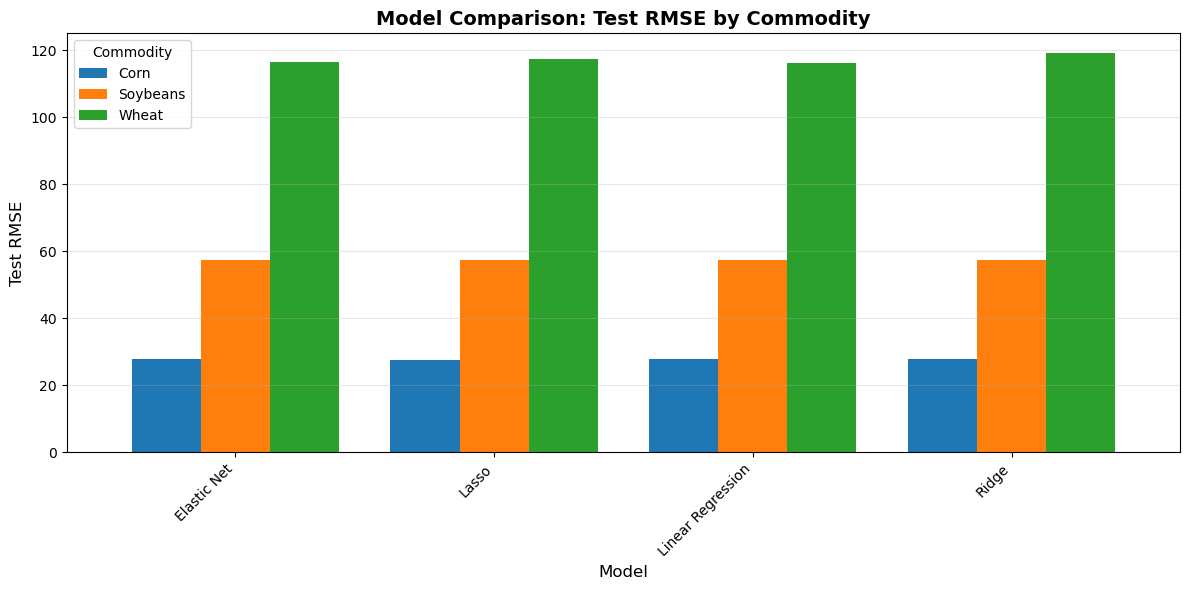

✓ Gráfico guardado: reports/figures/baseline_models_comparison.png


In [11]:
# Plot comparativo
fig, ax = plt.subplots(figsize=(12, 6))

comparison_pivot = comparison_df.pivot(index='Model', columns='Commodity', values='Test RMSE')
comparison_pivot.plot(kind='bar', ax=ax, width=0.8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Test RMSE', fontsize=12)
ax.set_title('Model Comparison: Test RMSE by Commodity', fontsize=14, fontweight='bold')
ax.legend(title='Commodity', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'figures' / 'baseline_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: reports/figures/baseline_models_comparison.png")

---

## 6. Guardar Modelos y Resultados

In [12]:
import pickle

# Guardar modelos
models_dir = BASE_DIR / 'models'
models_dir.mkdir(exist_ok=True)

# Guardar todos los modelos en un diccionario
all_models = {
    'linear_regression': lr_models,
    'ridge': ridge_models,
    'lasso': lasso_models,
    'elastic_net': enet_models,
    'scaling_stats': scaling_stats,  # Guardar stats (mean/std) en lugar de scaler
    'feature_cols': feature_cols
}

models_file = models_dir / 'baseline_models.pkl'
with open(models_file, 'wb') as f:
    pickle.dump(all_models, f)

print(f"✓ Modelos guardados: {models_file}")

# Guardar resultados en JSON
results_summary = {
    'fecha_generacion': pd.Timestamp.now().isoformat(),
    'models': ['Linear Regression', 'Ridge', 'Lasso', 'Elastic Net'],
    'commodities': TARGET_COMMODITIES,
    'split_date': split_date,
    'results': comparison_df.to_dict(orient='records'),
    'best_models': {},
    'hyperparameters': {
        'ridge_alphas': ridge_best_alphas,
        'lasso_alphas': lasso_best_alphas,
        'enet_params': enet_best_params
    },
    'feature_selection': {
        'lasso': {c: len(feats) for c, feats in lasso_selected_features.items()}
    }
}

# Identificar mejor modelo por commodity
for commodity in TARGET_COMMODITIES:
    commodity_results = comparison_df[comparison_df['Commodity'] == commodity].sort_values('Test RMSE')
    results_summary['best_models'][commodity] = commodity_results.iloc[0]['Model']

results_file = PROCESSED_DIR / 'baseline_models_results.json'
with open(results_file, 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"✓ Resultados guardados: {results_file}")

✓ Modelos guardados: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models\baseline_models.pkl
✓ Resultados guardados: C:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\baseline_models_results.json
